In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

### Contexte
Les data scientists à l'origine de la newsletter souhaitent mieux comprendre le comportement des utilisateurs qui visitent leur site web. 

- possible de constuire un modèle capable de prédire si un utilisateur donné s'abonnera à la newsletter
- identifier nouveaux leviers d'actions pour augmenter taux de conversions? (moment où l'utilisateur s'abonne à la newsletter)

### Read file

In [2]:
data_train = pd.read_csv('data/conversion_data_train.csv')
print('Set with labels (our train+test) :', data_train.shape)
print(data_train.head())
print(data_train.info())

Set with labels (our train+test) : (284580, 6)
   country  age  new_user  source  total_pages_visited  converted
0    China   22         1  Direct                    2          0
1       UK   21         1     Ads                    3          0
2  Germany   20         0     Seo                   14          1
3       US   23         1     Seo                    3          0
4       US   28         1  Direct                    3          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+

### EDA

In [3]:
print("Basics statistics: ")
display(data_train.describe(include='all'))
print()

print("Percentage of missing values: ")
print(data_train.isna().sum()/data_train.shape[0]*100)
print()

Basics statistics: 


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000



Percentage of missing values: 
country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64



/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_78568/725703744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_train, x=col, ax=ax, palette='Set2')


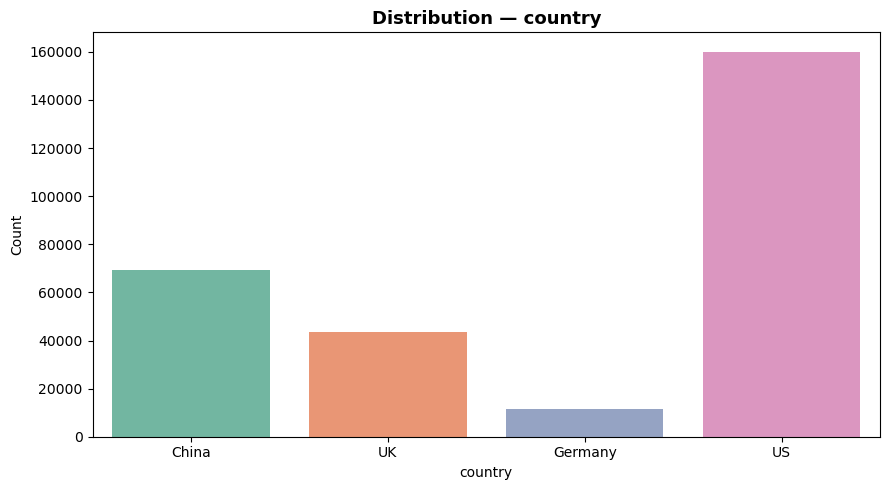

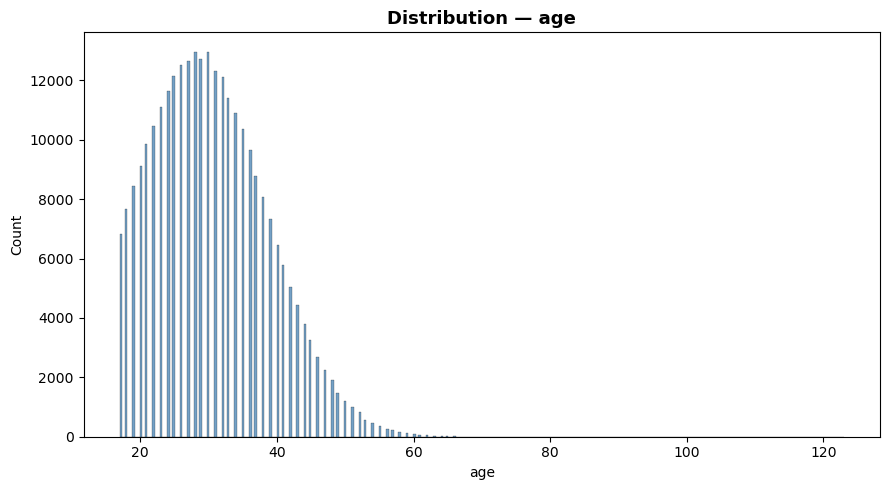

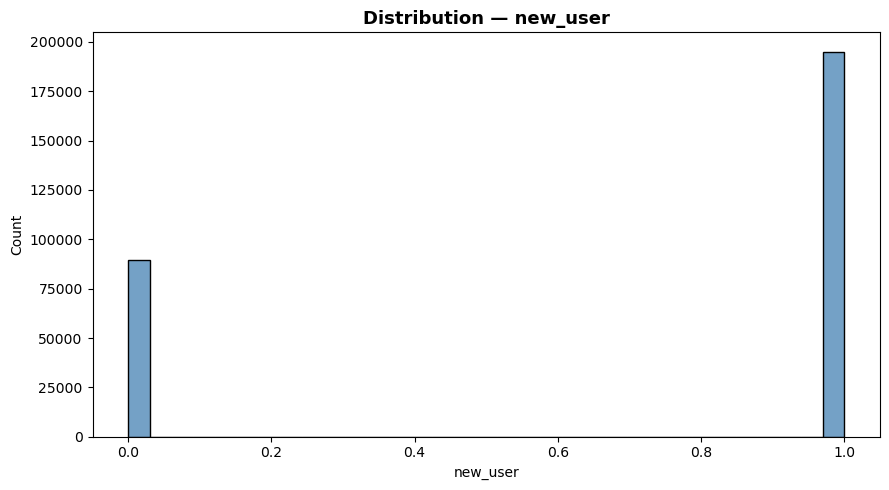

/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_78568/725703744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_train, x=col, ax=ax, palette='Set2')


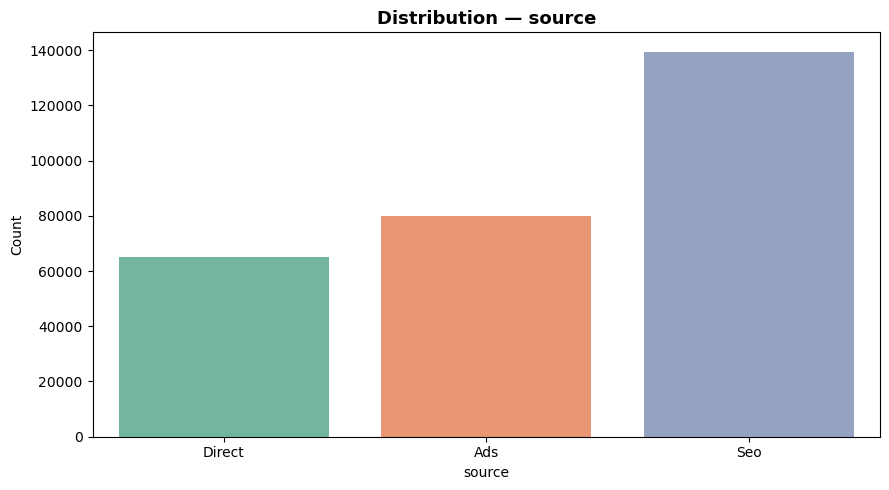

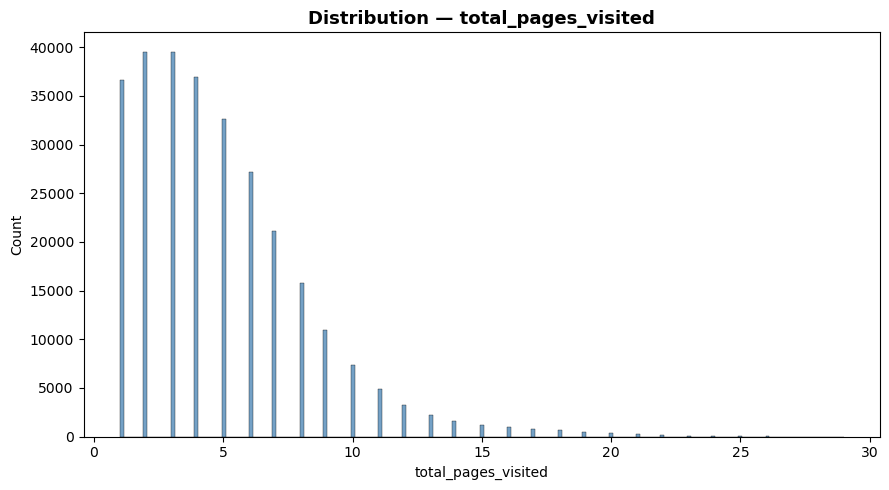

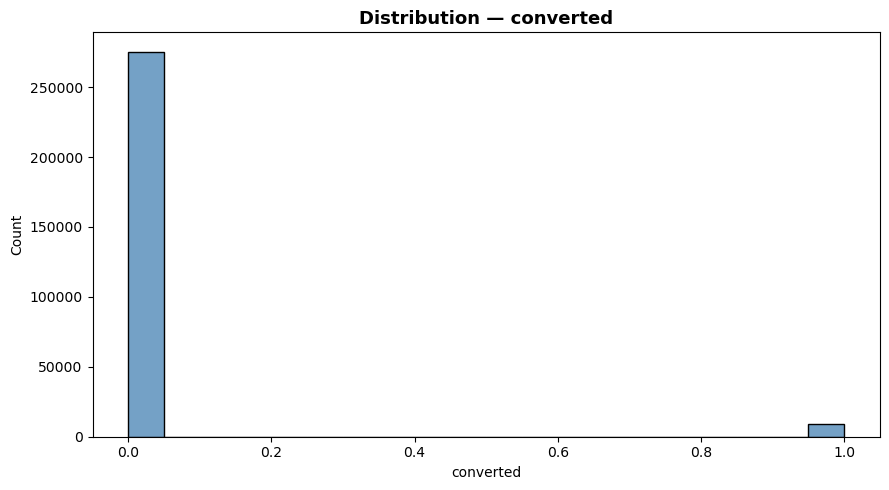

In [4]:
for col in data_train.columns:
    f, ax = plt.subplots(figsize=(9, 5))
    
    if data_train[col].dtype == 'object':
        sns.countplot(data=data_train, x=col, ax=ax, palette='Set2')
    else:
        sns.histplot(data=data_train, x=col, ax=ax, color='steelblue')
    
    ax.set_title(f'Distribution — {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

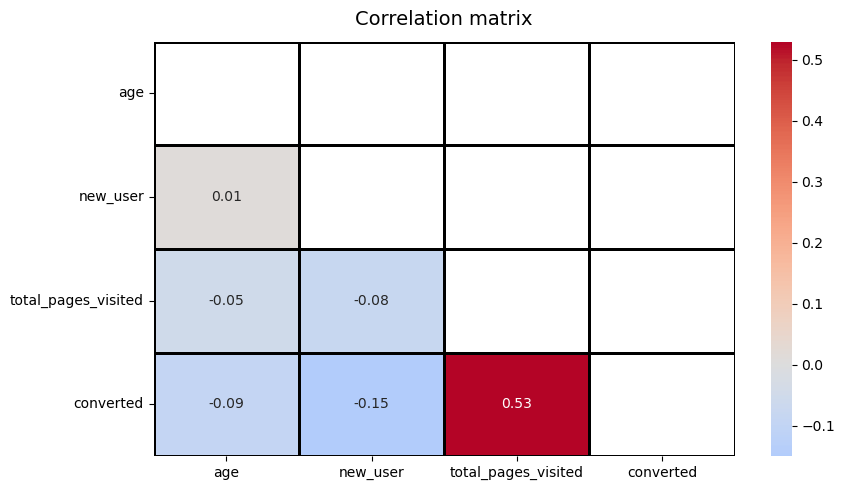

In [5]:
# Correlation matrix
corr_matrix = data_train.corr(numeric_only=True).round(2)
f, ax = plt.subplots(figsize=(9, 5))
mask_sns = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask_sns, annot=True, center=0,
            cmap="coolwarm", linewidths=1, fmt=".2f",
            linecolor="black", cbar_kws={"shrink": 1, "orientation": "vertical"})
ax.set_title("Correlation matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that the most useful feature is total_pages_visited. Let's create a baseline model by using at first only this feature : in the next cells, we'll make preprocessings and train a simple (univariate) logistic regression.**

### Features selections

In [6]:
features_list       = ['total_pages_visited']
numeric_features    = ['total_pages_visited']
categorical_features = []
target_variable     = 'converted'

### Training pipeline

In [7]:
X = data_train.loc[:, features_list]
Y = data_train.loc[:, target_variable]
print('\nExplanatory variables:', X.columns.tolist())
print('Target variable:', Y.name)

#Split
print("\nDividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")

#Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

#Pipeline complète
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression())
])

#Entraînement
print("\nTraining model...")
pipeline.fit(X_train, Y_train)
print("...Done.")

#Prédictions
print("\nPredictions on training set...")
Y_train_pred = pipeline.predict(X_train)
print("...Done.")

print("\nPredictions on test set...")
Y_test_pred = pipeline.predict(X_test)
print("...Done.")



Explanatory variables: ['total_pages_visited']
Target variable: converted

Dividing into train and test sets...
...Done.

Training model...
...Done.

Predictions on training set...
...Done.

Predictions on test set...
...Done.


## Performance assessment

In [8]:
def evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred):
    print(f"\nF1-score — Train : {f1_score(Y_train, Y_train_pred):.4f}  |  Test : {f1_score(Y_test, Y_test_pred):.4f}")

    print(f"\nConfusion Matrix :")
    cm_train = pd.DataFrame(
        confusion_matrix(Y_train, Y_train_pred),
        index=['Réel : 0', 'Réel : 1'],
        columns=['Prédit : 0', 'Prédit : 1']
    )
    cm_test = pd.DataFrame(
        confusion_matrix(Y_test, Y_test_pred),
        index=['Réel : 0', 'Réel : 1'],
        columns=['Prédit : 0', 'Prédit : 1']
    )
    print(pd.concat([cm_train, cm_test], axis=1, keys=['Train', 'Test']))

    print(f"\nClassification Report — Train :")
    print(classification_report(Y_train, Y_train_pred, target_names=['Non converti', 'Converti']))
    print(f"Classification Report — Test :")
    print(classification_report(Y_test, Y_test_pred, target_names=['Non converti', 'Converti']))

evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred)


F1-score — Train : 0.6939  |  Test : 0.7060

Confusion Matrix :
              Train                  Test           
         Prédit : 0 Prédit : 1 Prédit : 0 Prédit : 1
Réel : 0     246817       1082      27384        117
Réel : 1       3280       4943        371        586

Classification Report — Train :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99    247899
    Converti       0.82      0.60      0.69      8223

    accuracy                           0.98    256122
   macro avg       0.90      0.80      0.84    256122
weighted avg       0.98      0.98      0.98    256122

Classification Report — Test :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99     27501
    Converti       0.83      0.61      0.71       957

    accuracy                           0.98     28458
   macro avg       0.91      0.80      0.85     28458
weighted avg       0.98      0.98      0.98     28458



F1 train (0.694) ≈ F1 test (0.706) → pas d'overfitting, bonne généralisation du modèle

Precision sur Converti élevée (0.82/0.83) → quand il prédit une conversion, il a rarement tort (faux positifs: TP/(TP + FP))

Recall sur Converti faible (0.60/0.61) → le modèle rate 40% des vrais convertis (faux négatifs: TP / (TP + FN))

### Predictions on data_test -> X_without_labels

In [9]:
# Read data without labels
data_without_labels = pd.read_csv('data/conversion_data_test.csv')
print('\nPrediction set (without labels) :', data_without_labels.shape)

X_without_labels = data_without_labels.loc[:, features_list]
print(X_without_labels.head())

# Prédictions
Y_without_labels_pred = pipeline.predict(X_without_labels)
print("\nPrédictions sur les data_test (5 premières) :", Y_without_labels_pred[:5])



Prediction set (without labels) : (31620, 5)
   total_pages_visited
0                   16
1                    5
2                    1
3                    6
4                    3

Prédictions sur les data_test (5 premières) : [1 0 0 0 0]


### All features

In [10]:
features_list        = ['total_pages_visited', 'age', 'new_user', 'country', 'source']
numeric_features     = ['total_pages_visited', 'age', 'new_user']
categorical_features = ['country', 'source']

X = data_train.loc[:, features_list]
Y = data_train.loc[:, target_variable]
print('\nExplanatory variables:', X.columns.tolist())
print('Target variable:', Y.name)

#Split
print("\nDividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")

#Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

#Pipeline complète
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression())
])

#Entraînement
print("\nTraining model...")
pipeline.fit(X_train, Y_train)
print("...Done.")

#Prédictions
print("\nPredictions on training set...")
Y_train_pred = pipeline.predict(X_train)
print("...Done.")

print("\nPredictions on test set...")
Y_test_pred = pipeline.predict(X_test)
print("...Done.")

evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred)


Explanatory variables: ['total_pages_visited', 'age', 'new_user', 'country', 'source']
Target variable: converted

Dividing into train and test sets...
...Done.

Training model...
...Done.

Predictions on training set...
...Done.

Predictions on test set...
...Done.

F1-score — Train : 0.7640  |  Test : 0.7560

Confusion Matrix :
              Train                  Test           
         Prédit : 0 Prédit : 1 Prédit : 0 Prédit : 1
Réel : 0     246954        945      27395        106
Réel : 1       2556       5667        311        646

Classification Report — Train :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99    247899
    Converti       0.86      0.69      0.76      8223

    accuracy                           0.99    256122
   macro avg       0.92      0.84      0.88    256122
weighted avg       0.99      0.99      0.99    256122

Classification Report — Test :
              precision    recall  f1-score   support

Non conve

Pas vraiment d'amélioration après avoir ajouté les autres features -> total_pages_visited domine complétement le modèle

#### Check coefficients

Les Coefficients ne représentent pas directement une probabilité, mais log-odds:
logarithme de la probabilité de conversion par rapport à la probabilité de non-conversion.

Importance des features
            feature  coefficient
    country_Germany     3.580450
         country_UK     3.427189
         country_US     3.086436
total_pages_visited     2.521237
         source_Seo    -0.015412
      source_Direct    -0.229849
                age    -0.606424
           new_user    -0.813200


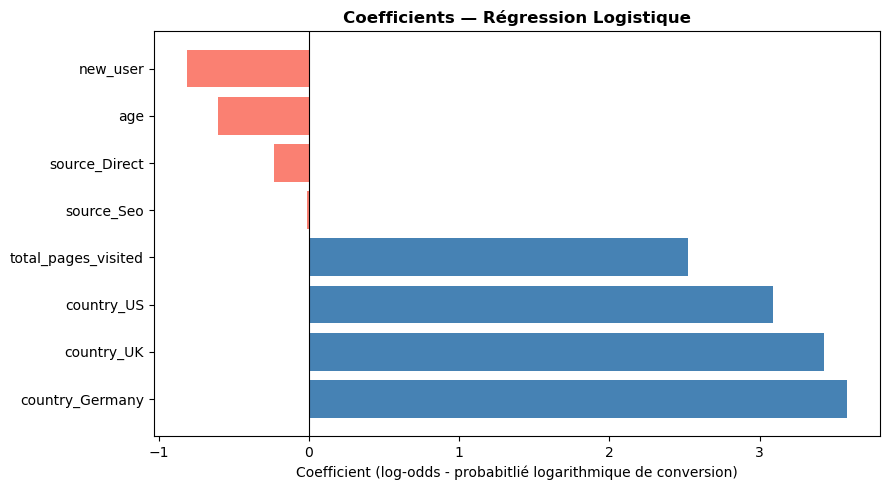

In [11]:
# Récupérer les vrais noms de features après encoding
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

all_features = numeric_features + cat_feature_names

# Récupérer les coefficients
coefs = pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature'    : all_features,
    'coefficient': coefs
}).sort_values('coefficient', ascending=False)

print("Les Coefficients ne représentent pas directement une probabilité, mais log-odds:") 
print("logarithme de la probabilité de conversion par rapport à la probabilité de non-conversion.")
print("\nImportance des features")

print(coef_df.to_string(index=False))

# Visualisation
f, ax = plt.subplots(figsize=(9, len(all_features) * 0.5 + 1))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coefficients — Régression Logistique', fontweight='bold')
ax.set_xlabel('Coefficient (log-odds - probabitlié logarithmique de conversion)')
plt.tight_layout()
plt.show()

### Conclusion avec modèle Regression Logistique:
- pages visitées: plus un utilisateur visites des pages, plus il est susceptible de convertir
- localisation: effet le plus fort les utilisateurs en Allemagne, puis UK, puis USA sont bien plus susceptibles de convertir que les autres pays (ici référence = Chine, après drop_first)
- source de trafic: effet neutre -> source Seo aet Source direct -> coeff quasi nuls -> la source du trafic n'influe presuqe par la conversion
- profil utilisateur -> les utilisateurs les plus âgés convertissent moins et les nouveaux utilisateurs convertissent moins que les utilisateurs existants -> les utilisateurs récurrents sont plus engagés

### Autre modèle

In [12]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=0
        )) #
])

#Entraînement
print("\nTraining model...")
pipeline.fit(X_train, Y_train)
print("...Done.")

#Prédictions
print("\nPredictions on training set...")
Y_train_pred = pipeline.predict(X_train)
print("...Done.")

print("\nPredictions on test set...")
Y_test_pred = pipeline.predict(X_test)
print("...Done.")

evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred)


Training model...
...Done.

Predictions on training set...
...Done.

Predictions on test set...
...Done.

F1-score — Train : 0.8009  |  Test : 0.7506

Confusion Matrix :
              Train                  Test           
         Prédit : 0 Prédit : 1 Prédit : 0 Prédit : 1
Réel : 0     247138        761      27361        140
Réel : 1       2222       6001        298        659

Classification Report — Train :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99    247899
    Converti       0.89      0.73      0.80      8223

    accuracy                           0.99    256122
   macro avg       0.94      0.86      0.90    256122
weighted avg       0.99      0.99      0.99    256122

Classification Report — Test :
              precision    recall  f1-score   support

Non converti       0.99      0.99      0.99     27501
    Converti       0.82      0.69      0.75       957

    accuracy                           0.98     28458
   macro

- F1 test meilleur que Logisitic regression 
- Recall +8 points vs Logisitic regression (détecte plus de vrais convertis)
- Precision quasi identique
- Légèrement plus de faux positifs

- Petit gap train/test (0.80 vs 0.75) — signe d'un léger overfitting -> ajuster hyperparamètres 

In [13]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,        # Limiter la profondeur des arbres
            min_samples_leaf=5,  # Éviter les feuilles trop spécifiques
            random_state=0
        )) #
])

#Entraînement
print("\nTraining model...")
pipeline.fit(X_train, Y_train)
print("...Done.")

#Prédictions
print("\nPredictions on training set...")
Y_train_pred = pipeline.predict(X_train)
print("...Done.")

print("\nPredictions on test set...")
Y_test_pred = pipeline.predict(X_test)
print("...Done.")

evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred)


Training model...
...Done.

Predictions on training set...
...Done.

Predictions on test set...
...Done.

F1-score — Train : 0.7742  |  Test : 0.7587

Confusion Matrix :
              Train                  Test           
         Prédit : 0 Prédit : 1 Prédit : 0 Prédit : 1
Réel : 0     247026        873      27388        113
Réel : 1       2478       5745        303        654

Classification Report — Train :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99    247899
    Converti       0.87      0.70      0.77      8223

    accuracy                           0.99    256122
   macro avg       0.93      0.85      0.88    256122
weighted avg       0.99      0.99      0.99    256122

Classification Report — Test :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99     27501
    Converti       0.85      0.68      0.76       957

    accuracy                           0.99     28458
   macro

Overfitting éliminé.

Essaie avec class_weight pour prendre en compte le dataset déséquilibré (nbre de non-converti VS converti)

In [14]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,        # Limiter la profondeur des arbres
            min_samples_leaf=5,  # Éviter les feuilles trop spécifiques
            random_state=0,
            class_weight='balanced'  # Gérer le déséquilibre de classes -> pénaliser davantage les erreurs sur la classe minoritaire (ici Converti = 1)
        )) #
])

#Entraînement
print("\nTraining model...")
pipeline.fit(X_train, Y_train)
print("...Done.")

#Prédictions
print("\nPredictions on training set...")
Y_train_pred = pipeline.predict(X_train)
print("...Done.")

print("\nPredictions on test set...")
Y_test_pred = pipeline.predict(X_test)
print("...Done.")

evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred)


Training model...
...Done.

Predictions on training set...
...Done.

Predictions on test set...
...Done.

F1-score — Train : 0.5582  |  Test : 0.5622

Confusion Matrix :
              Train                  Test           
         Prédit : 0 Prédit : 1 Prédit : 0 Prédit : 1
Réel : 0     236111      11788      26205       1296
Réel : 1        476       7747         76        881

Classification Report — Train :
              precision    recall  f1-score   support

Non converti       1.00      0.95      0.97    247899
    Converti       0.40      0.94      0.56      8223

    accuracy                           0.95    256122
   macro avg       0.70      0.95      0.77    256122
weighted avg       0.98      0.95      0.96    256122

Classification Report — Test :
              precision    recall  f1-score   support

Non converti       1.00      0.95      0.97     27501
    Converti       0.40      0.92      0.56       957

    accuracy                           0.95     28458
   macro

Moins bon score que sans class_weight balanced. -> garder résultat précédent.


Training model...
...Done.

Predictions on training set...
...Done.

Predictions on test set...
...Done.

F1-score — Train : 0.7742  |  Test : 0.7587

Confusion Matrix :
              Train                  Test           
         Prédit : 0 Prédit : 1 Prédit : 0 Prédit : 1
Réel : 0     247026        873      27388        113
Réel : 1       2478       5745        303        654

Classification Report — Train :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99    247899
    Converti       0.87      0.70      0.77      8223

    accuracy                           0.99    256122
   macro avg       0.93      0.85      0.88    256122
weighted avg       0.99      0.99      0.99    256122

Classification Report — Test :
              precision    recall  f1-score   support

Non converti       0.99      1.00      0.99     27501
    Converti       0.85      0.68      0.76       957

    accuracy                           0.99     28458
   macro

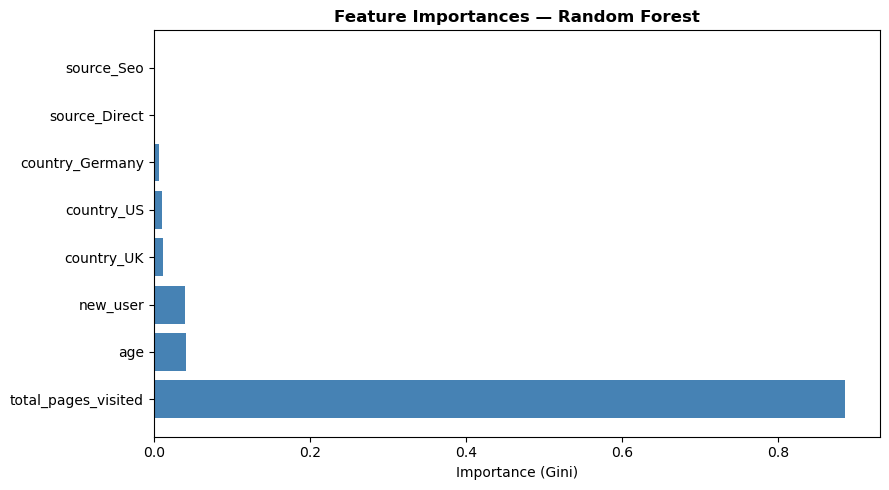

In [15]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,        # Limiter la profondeur des arbres
            min_samples_leaf=5,  # Éviter les feuilles trop spécifiques
            random_state=0
        )) #
])

#Entraînement
print("\nTraining model...")
pipeline.fit(X_train, Y_train)
print("...Done.")

#Prédictions
print("\nPredictions on training set...")
Y_train_pred = pipeline.predict(X_train)
print("...Done.")

print("\nPredictions on test set...")
Y_test_pred = pipeline.predict(X_test)
print("...Done.")

evaluate_model(Y_train, Y_train_pred, Y_test, Y_test_pred)

# Récupérer les feature importances
all_features = pipeline.named_steps['preprocessor'].get_feature_names_out().tolist()
all_features = [f.replace('num__', '').replace('cat__', '') for f in all_features]

importances = pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'feature'   : all_features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nImportance des features (Random Forest)")
print(importance_df.to_string(index=False))

# Visualisation
f, ax = plt.subplots(figsize=(9, len(all_features) * 0.5 + 1))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importances — Random Forest', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

In [16]:
# ANalyse par classe pour mieux comprendre les différences entre les convertis et les non-convertis
for feat in numeric_features:
    print(f"\n{feat} :")
    print(data_train.groupby('converted')[feat].mean().round(2))

for feat in categorical_features:
    print(f"\nTaux de conversion par {feat} :")
    print(data_train.groupby(feat)['converted'].mean().sort_values(ascending=False).round(3))


total_pages_visited :
converted
0     4.55
1    14.56
Name: total_pages_visited, dtype: float64

age :
converted
0    30.70
1    26.57
Name: age, dtype: float64

new_user :
converted
0    0.7
1    0.3
Name: new_user, dtype: float64

Taux de conversion par country :
country
Germany    0.062
UK         0.052
US         0.038
China      0.001
Name: converted, dtype: float64

Taux de conversion par source :
source
Ads       0.035
Seo       0.033
Direct    0.028
Name: converted, dtype: float64


### Conclusion avec Modèle Random Forest:
- pages visitées: signla le plus fort : plus un utilisateur visites des pages, plus il est susceptible de convertir
- âge: les convertis sont 4ans plus jeunes en moyenne que les non converties (30,7ans)
- nouveaux utilisateurs: les visiteurs récurrents convertissent 2x plus 
- pays: la Chine ne convertit quasi pas (0,1%) c'est probablement la référence après drop_first ce qui expliquait les forts coefficients positifs pour les 3 autres pays
- source du trafic: Différences minimes — la source n'a presque aucun impact

### Recommendation globale
- inciter à visiter plus de pages (navigation guidée, recommandation contenu lié)
- convertir les nouveaux en récurrents (compte utilisateur, push)
- cibler Allemagne et UK. Pourquoi la Chine ne convertit pas? barrière linguistique ou autre?
- adapter le contenu aux 20-27ans
- source: ne pas surinvestir sur Ads, Seo ou direct -> différence négligeable
